# DM verification notebook: `nq=8` 3-panel accuracy comparison

This notebook follows the density-matrix flow from `quantum_run_dm_verification.py` and compares protocol accuracy versus preparation-noise amplitude for:

1. relaxation
2. dephasing
3. both channels applied sequentially (relaxation then dephasing)

Requested settings:
- `nq = 8`
- amplitudes in log space from `0.005` to `0.2`
- `nf = 1000`
- `|alpha| = 1, 4, 8`
- perfect gate fidelities (`f1q = f2q = 1`) and perfect readout

In [16]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorcircuit as tc

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
K = tc.set_backend("jax")

# Ensure local modules are importable when running from this folder
if str(Path("modules").resolve()) not in sys.path:
    sys.path.append(str(Path("modules").resolve()))

import quantum_device_sim as qd
import quantum_run_mc_optimized as qrmc_opt
import device_config as dc
from shadow_mcs_jitted import generate_psi_F_vector

In [17]:
def build_alpha_with_weight(nq: int, weight: int) -> np.ndarray:
    """Pattern consistent with quantum_run_dm_verification.py: first (w-1) ones, last qubit one."""
    if weight < 1 or weight > nq:
        raise ValueError(f"weight must be in [1, nq], got {weight} for nq={nq}")
    alpha = np.zeros(nq, dtype=np.int32)
    alpha[: weight - 1] = 1
    alpha[-1] = 1
    return alpha


def run_dm_simulation_for_one_state(
    initial_state_vector,
    transpiled_template,
    shots,
    mapping,
    prep_channel_kraus_list,
    f_state_idx,
):
    """
    DM simulation mirroring the file logic, with ideal gate/readout assumptions.
    """
    if hasattr(transpiled_template, "nqubits"):
        nq = transpiled_template.nqubits
    elif hasattr(transpiled_template, "n"):
        nq = transpiled_template.n
    elif hasattr(transpiled_template, "qubits"):
        nq = len(transpiled_template.qubits)
    elif hasattr(transpiled_template, "circuit_param") and "nqubits" in transpiled_template.circuit_param:
        nq = transpiled_template.circuit_param["nqubits"]
    else:
        raise AttributeError("Could not infer number of qubits from transpiled_template")

    psi0 = jnp.array(initial_state_vector, dtype=jnp.complex128)
    rho0 = jnp.outer(psi0, jnp.conj(psi0))

    # Apply preparation channel(s) to each qubit (relaxation, dephasing, or both)
    rho0_dm = tc.DMCircuit(nq, dminputs=rho0)
    for ks in prep_channel_kraus_list:
        if hasattr(ks, "shape") and len(ks.shape) == 3:
            ks_list = [ks[i] for i in range(ks.shape[0])]
        elif isinstance(ks, list):
            ks_list = ks
        else:
            ks_list = [ks]

        # Convert to TensorCircuit tensor objects for compatibility across versions
        ks_tc = [tc.array_to_tensor(jnp.array(k, dtype=jnp.complex128)) for k in ks_list]

        for q in range(nq):
            rho0_dm.general_kraus(ks_tc, q)
    rho0 = rho0_dm.state()

    dmc = tc.DMCircuit(nq, dminputs=rho0)
    qir = transpiled_template.to_qir()

    # Perfect f1q/f2q => no gate depolarizing channel, apply only unitary gates
    for gate_info in qir:
        gate_name = gate_info.get("name", "").lower()
        qubits = gate_info.get("index", [])
        params = gate_info.get("parameters", {})

        if gate_name == "h" and len(qubits) > 0:
            dmc.h(qubits[0])
        elif (gate_name == "cx" or gate_name == "cnot") and len(qubits) >= 2:
            dmc.cx(qubits[0], qubits[1])
        elif gate_name == "rz" and len(qubits) > 0:
            dmc.rz(qubits[0], theta=params.get("theta", 0.0))
        elif gate_name == "ry" and len(qubits) > 0:
            dmc.ry(qubits[0], theta=params.get("theta", 0.0))
        elif gate_name == "rx" and len(qubits) > 0:
            dmc.rx(qubits[0], theta=params.get("theta", 0.0))

    base_key = jax.random.PRNGKey(42)
    key = jax.random.fold_in(base_key, int(f_state_idx) * 20000)
    keys = jax.random.split(key, shots)

    def sample_one(sample_key):
        out = dmc.sample(allow_state=True, random_generator=sample_key)
        return out[0] if isinstance(out, (list, tuple)) else out

    samples = jax.vmap(sample_one)(keys)
    if mapping is not None:
        samples = samples[:, mapping]
    return samples

In [18]:
# Requested experiment settings
NQ = 8
NF = 1000
SHOTS_PER_F = 1000
F_SEED = 42
DEVICE = "I"  # all-to-all; we keep topology handling from project utilities
ALPHA_WEIGHTS = [1, 4, 8]
AMPLITUDES = np.logspace(np.log10(0.005), np.log10(0.2), 16)

# Perfect gate/readout assumptions
F1Q = 1.0
F2Q = 1.0
READOUT_ERROR = 0.0

connectivity = dc.get_connectivity_for_device(DEVICE, NQ)
perfect_noise_conf = [F1Q, F2Q]

dev = qd.QuantumDeviceSimulator(
    NQ,
    dc.QISKIT_BASIS_GATES,
    connectivity,
    perfect_noise_conf,
    READOUT_ERROR,
    T1=1e12,
    T2=1e12,
    delay_gate_configs=[],
    Tidle=1e12,
)

templates, map_data, _, _, _, template_cnots, _ = qd.precompute_transpiled_templates(NQ, dev)
mappings_jax = {k: jnp.array(v if v is not None else np.arange(NQ), dtype=jnp.int32) for k, v in map_data.items()}

np.random.seed(F_SEED)
F_matrix = np.random.randint(2, size=(NF, 2**NQ)).astype(np.int32)

print(f"Prepared templates for nq={NQ}, NF={NF}, amplitudes={len(AMPLITUDES)}")


Pre-computing transpiled circuit templates for nq=4...


Transpiling templates:   0%|          | 0/4 [00:00<?, ?it/s]

Transpiling templates: 100%|██████████| 4/4 [00:06<00:00,  1.75s/it]

✅ All templates pre-computed and cached.
Prepared templates for nq=4, NF=100, amplitudes=16


In [19]:
def get_prep_channels(channel_name: str, amp: float):
    if channel_name == "relaxation":
        return [qrmc_opt.get_kraus_operators_with_aliases({"type": "relaxation", "strength": float(amp)})]
    if channel_name == "dephasing":
        return [qrmc_opt.get_kraus_operators_with_aliases({"type": "dephasing", "strength": float(amp)})]
    if channel_name == "both":
        k_relax = qrmc_opt.get_kraus_operators_with_aliases({"type": "relaxation", "strength": float(amp)})
        k_deph = qrmc_opt.get_kraus_operators_with_aliases({"type": "dephasing", "strength": float(amp)})
        # Sequential application approximates "adding" both channels into one prep stage
        return [k_relax, k_deph]
    raise ValueError(f"Unknown channel: {channel_name}")


def run_curve_for_channel_and_alpha(channel_name: str, amp: float, alpha_weight: int):
    alpha = build_alpha_with_weight(NQ, alpha_weight)
    alpha_sum = int(alpha.sum())
    template = templates[alpha_sum]
    mapping = mappings_jax[alpha_sum]
    prep_channels = get_prep_channels(channel_name, amp)

    accs = np.zeros(NF, dtype=np.float64)
    for label in range(NF):
        f_vec = jnp.array(F_matrix[label], dtype=jnp.int32)
        psi0 = generate_psi_F_vector(f_vec, NQ)

        samples = run_dm_simulation_for_one_state(
            psi0,
            template,
            SHOTS_PER_F,
            mapping,
            prep_channels,
            f_state_idx=label,
        )

        acc = qrmc_opt.process_results_to_accuracy(
            samples,
            jnp.arange(NQ, dtype=jnp.int32),
            f_vec,
            jnp.array(alpha, dtype=jnp.int32),
            NQ,
            NQ,
        )
        accs[label] = float(acc)

    return {
        "mean": float(np.mean(accs)),
        "std": float(np.std(accs)),
        "all": accs,
    }

In [20]:
CHANNELS = ["relaxation", "dephasing", "both"]
results = {
    ch: {
        w: {"amp": [], "mean": [], "std": []}
        for w in ALPHA_WEIGHTS
    }
    for ch in CHANNELS
}

for ch in CHANNELS:
    print(f"\nRunning channel: {ch}")
    for w in ALPHA_WEIGHTS:
        print(f"  |alpha|={w}")
        for amp in tqdm(AMPLITUDES, desc=f"{ch} |alpha|={w}"):
            out = run_curve_for_channel_and_alpha(ch, float(amp), w)
            results[ch][w]["amp"].append(float(amp))
            results[ch][w]["mean"].append(out["mean"])
            results[ch][w]["std"].append(out["std"])

# Optional save
out_path = Path("dm_nq8_relaxation_dephasing_3panel_results.json")
with out_path.open("w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)
print(f"Saved results to {out_path.resolve()}")


Running channel: relaxation
  |alpha|=1


relaxation |alpha|=1:   0%|          | 0/16 [00:00<?, ?it/s]

  |alpha|=4


relaxation |alpha|=4:   0%|          | 0/16 [00:00<?, ?it/s]


Running channel: dephasing
  |alpha|=1


...


Running channel: both
  |alpha|=1


both |alpha|=1:   0%|          | 0/16 [00:00<?, ?it/s]

  |alpha|=4


both |alpha|=4:   0%|          | 0/16 [00:00<?, ?it/s]

Saved results to /Users/krzywdaja/Documents/shadows/shadow-qml-cluster/code/quantum_simulation/dm_nq8_relaxation_dephasing_3panel_results.json


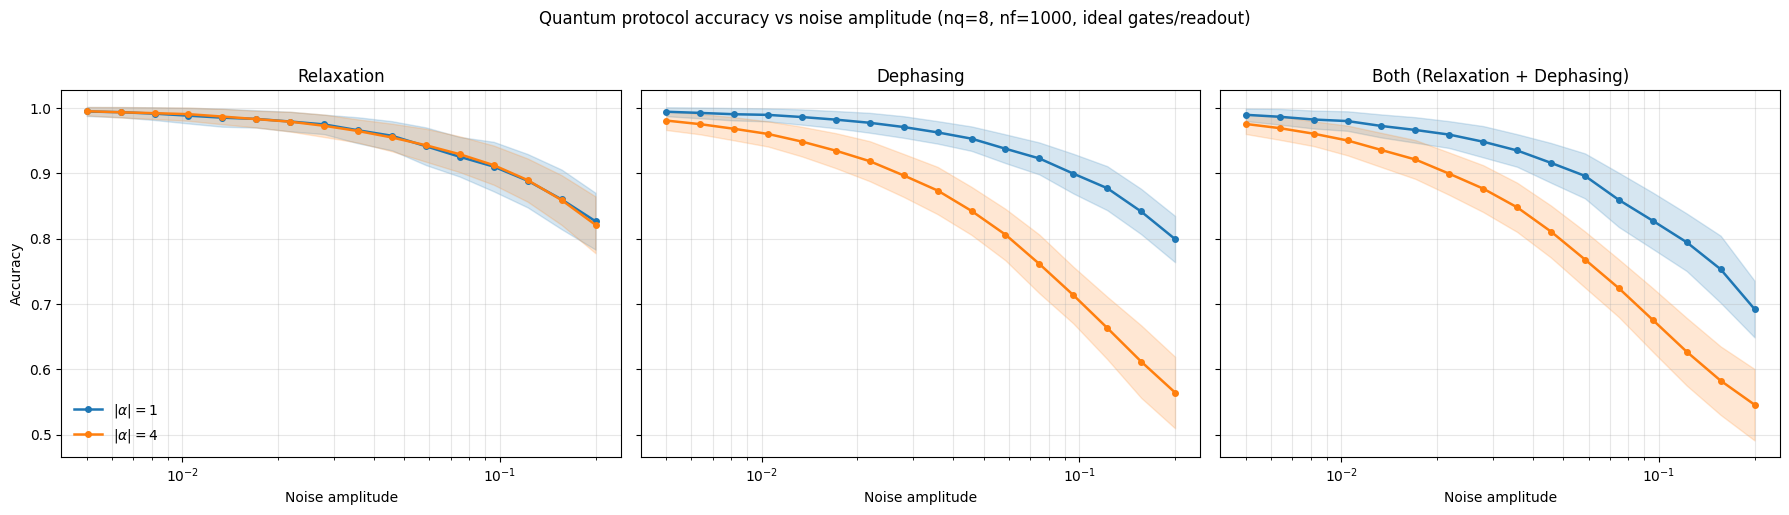

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
panel_titles = [
    "Relaxation",
    "Dephasing",
    "Both (Relaxation + Dephasing)",
]
panel_channels = ["relaxation", "dephasing", "both"]
colors = {1: "tab:blue", 4: "tab:orange", 8: "tab:green"}

for ax, title, ch in zip(axes, panel_titles, panel_channels):
    for w in ALPHA_WEIGHTS:
        amps = np.array(results[ch][w]["amp"])
        means = np.array(results[ch][w]["mean"])
        stds = np.array(results[ch][w]["std"])
        ax.plot(amps, means, marker="o", lw=1.8, ms=4, color=colors[w], label=fr"$|\alpha|={w}$")
        ax.fill_between(amps, means - stds, means + stds, color=colors[w], alpha=0.18)

    ax.set_xscale("log")
    ax.set_xlabel("Noise amplitude")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("Accuracy")
axes[0].legend(frameon=False)
fig.suptitle("Quantum protocol accuracy vs noise amplitude (nq=8, nf=1000, ideal gates/readout)", y=1.02)
fig.tight_layout()
plt.show()

## Notes

- The third panel uses sequential prep-noise application (`relaxation` then `dephasing`) as a concrete way to combine both channels.
- If you want a stricter channel-composition model, we can replace this with a single composed Kraus map per qubit.
- Runtime warning: this exact setup (`nf=1000`, multiple amplitudes, three channels) is computationally heavy for density-matrix simulation at `nq=8`.

In [22]:
# --- Theoretical predictions from Fig2_noise.ipynb ---
def acc_dephasing(p, d, nq):
    gamma = (1 - 2 * p) ** d
    return 0.5 * (1 + gamma)


def acc_relaxation(p, d, nq):
    gamma_active = np.sqrt(1 - p) ** d
    gamma_passive_avg = (1 - p / 2) ** (nq - d)
    return 0.5 * (1 + gamma_active * gamma_passive_avg)


def theory_curve(channel_name, p_values, d, nq):
    if channel_name == "dephasing":
        return np.array([acc_dephasing(float(p), d, nq) for p in p_values], dtype=np.float64)
    if channel_name == "relaxation":
        return np.array([acc_relaxation(float(p), d, nq) for p in p_values], dtype=np.float64)
    if channel_name == "both":
        # Approximation for composed channels: multiply gamma factors then map to accuracy
        g_rel = 2 * np.array([acc_relaxation(float(p), d, nq) for p in p_values]) - 1
        g_dep = 2 * np.array([acc_dephasing(float(p), d, nq) for p in p_values]) - 1
        return 0.5 * (1 + g_rel * g_dep)
    raise ValueError(f"Unknown channel: {channel_name}")

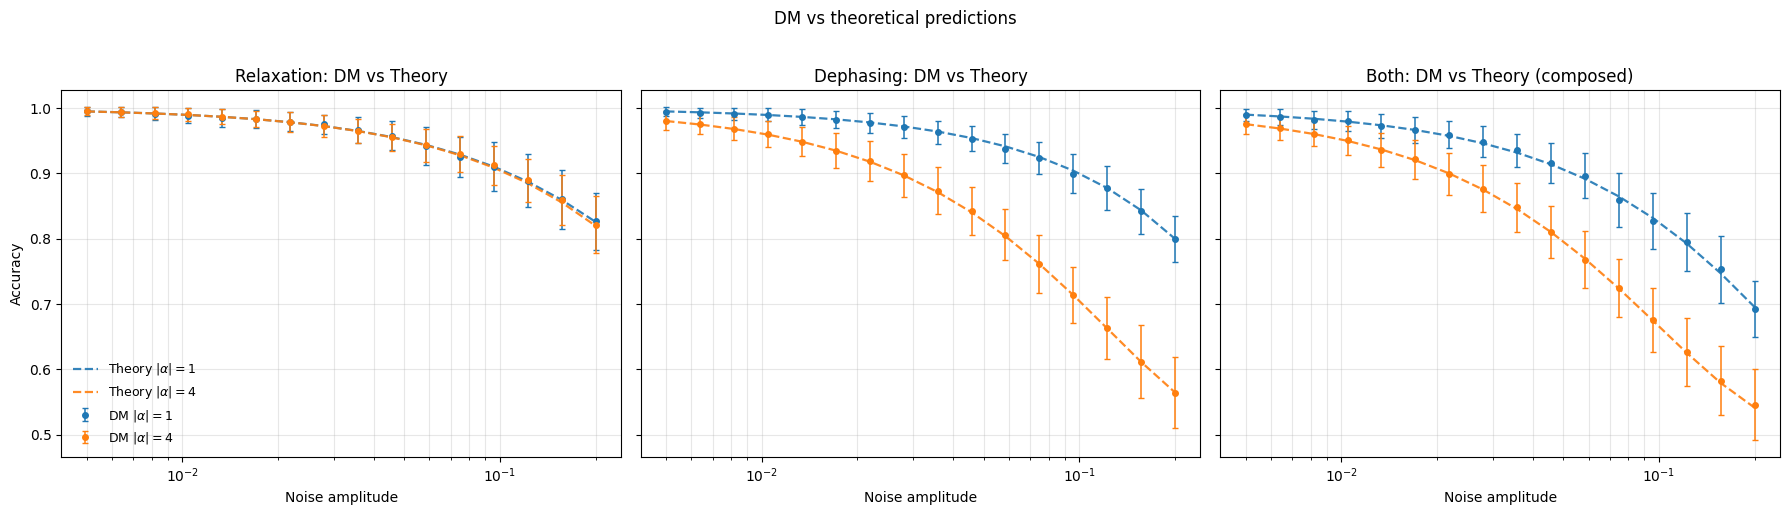

Comparison metrics (DM vs theory):

relaxation
  |alpha|=1: MAE=0.001147, RMSE=0.001484
  |alpha|=4: MAE=0.001190, RMSE=0.001847

dephasing
  |alpha|=1: MAE=0.001250, RMSE=0.001747
  |alpha|=4: MAE=0.000755, RMSE=0.001081

both
  |alpha|=1: MAE=0.002451, RMSE=0.003046
  |alpha|=4: MAE=0.001334, RMSE=0.001781


In [ ]:
# --- DM vs theory: error bars only for DM, theory as connecting line ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
panel_titles = [
    "Relaxation: DM vs Theory",
    "Dephasing: DM vs Theory",
    "Both: DM vs Theory (composed)",
]
panel_channels = ["relaxation", "dephasing", "both"]
colors = {1: "tab:blue", 4: "tab:orange", 8: "tab:green"}

comparison_metrics = {ch: {} for ch in panel_channels}

for ax, title, ch in zip(axes, panel_titles, panel_channels):
    for w in ALPHA_WEIGHTS:
        d = int(w)
        amps = np.array(results[ch][w]["amp"], dtype=np.float64)
        dm_mean = np.array(results[ch][w]["mean"], dtype=np.float64)
        dm_std = np.array(results[ch][w]["std"], dtype=np.float64)
        th = theory_curve(ch, amps, d, NQ)

        mae = float(np.mean(np.abs(dm_mean - th)))
        rmse = float(np.sqrt(np.mean((dm_mean - th) ** 2)))
        comparison_metrics[ch][w] = {"mae": mae, "rmse": rmse}

        # DM data: markers + vertical error bars, no connecting line
        ax.errorbar(
            amps,
            dm_mean,
            yerr=dm_std,
            fmt="o",
            linestyle="none",
            ms=4,
            elinewidth=1.1,
            capsize=2,
            color=colors[w],
            label=fr"DM $|\alpha|={w}$",
        )

        # Theory: connected dashed line
        ax.plot(amps, th, ls="--", lw=1.6, color=colors[w], alpha=0.9, label=fr"Theory $|\alpha|={w}$")

    ax.set_xscale("log")
    ax.set_xlabel("Noise amplitude")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("Accuracy")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("DM vs theoretical predictions", y=1.02)
fig.tight_layout()
plt.s

print("Comparison metrics (DM vs theory):")
for ch in panel_channels:
    print(f"\n{ch}")
    for w in ALPHA_WEIGHTS:
        m = comparison_metrics[ch][w]
        print(f"  |alpha|={w}: MAE={m['mae']:.6f}, RMSE={m['rmse']:.6f}")

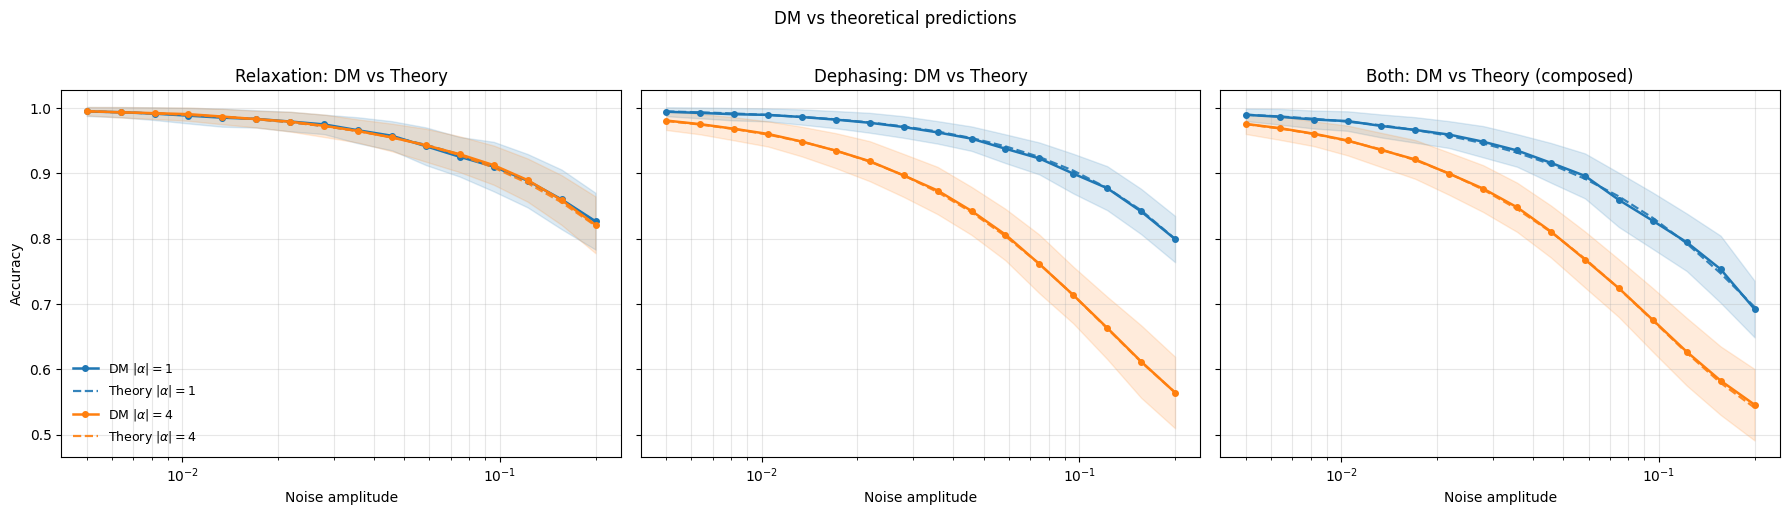

Comparison metrics (DM vs theory):

relaxation
  |alpha|=1: MAE=0.001147, RMSE=0.001484
  |alpha|=4: MAE=0.001190, RMSE=0.001847

dephasing
  |alpha|=1: MAE=0.001250, RMSE=0.001747
  |alpha|=4: MAE=0.000755, RMSE=0.001081

both
  |alpha|=1: MAE=0.002451, RMSE=0.003046
  |alpha|=4: MAE=0.001334, RMSE=0.001781


In [26]:
# --- Overlay DM data vs theory and print error metrics ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
panel_titles = [
    "Relaxation: DM vs Theory",
    "Dephasing: DM vs Theory",
    "Both: DM vs Theory (composed)",
]
panel_channels = ["relaxation", "dephasing", "both"]
colors = {1: "tab:blue", 4: "tab:orange", 8: "tab:green"}

comparison_metrics = {ch: {} for ch in panel_channels}

for ax, title, ch in zip(axes, panel_titles, panel_channels):
    for w in ALPHA_WEIGHTS:
        d = int(w)
        amps = np.array(results[ch][w]["amp"], dtype=np.float64)
        dm_mean = np.array(results[ch][w]["mean"], dtype=np.float64)
        dm_std = np.array(results[ch][w]["std"], dtype=np.float64)
        th = theory_curve(ch, amps, d, NQ)

        mae = float(np.mean(np.abs(dm_mean - th)))
        rmse = float(np.sqrt(np.mean((dm_mean - th) ** 2)))
        comparison_metrics[ch][w] = {"mae": mae, "rmse": rmse}

        ax.plot(amps, dm_mean, marker="o", lw=1.8, ms=4, color=colors[w], label=fr"DM $|\alpha|={w}$")
        ax.fill_between(amps, dm_mean - dm_std, dm_mean + dm_std, color=colors[w], alpha=0.15)
        ax.plot(amps, th, ls="--", lw=1.6, color=colors[w], alpha=0.9, label=fr"Theory $|\alpha|={w}$")

    ax.set_xscale("log")
    ax.set_xlabel("Noise amplitude")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("Accuracy")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("DM vs theoretical predictions", y=1.02)
fig.tight_layout()
plt.show()

print("Comparison metrics (DM vs theory):")
for ch in panel_channels:
    print(f"\n{ch}")
    for w in ALPHA_WEIGHTS:
        m = comparison_metrics[ch][w]
        print(f"  |alpha|={w}: MAE={m['mae']:.6f}, RMSE={m['rmse']:.6f}")

In [ ]:
from pathlib import Path
import matplotlib.lines as mlines

# Style consistent with figures_notebooks/fig1_relaxation_main.ipynb
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / '.git').exists():
    REPO_ROOT = REPO_ROOT.parent
plt.style.use(str(REPO_ROOT / 'figures_notebooks' / 'single_column.mplstyle'))

# --- DM vs theory: error bars only for DM, theory as connecting line ---
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), sharey=True, gridspec_kw={'wspace': 0.08})
panel_titles = [
    'Relaxation: DM vs Theory',
    'Dephasing: DM vs Theory',
    'Both: DM vs Theory (composed)',
]
panel_channels = ['relaxation', 'dephasing', 'both']
colors = {1: '#1f77b4', 4: '#ff7f0e', 8: '#2ca02c'}

comparison_metrics = {ch: {} for ch in panel_channels}

for ax, title, ch in zip(axes, panel_titles, panel_channels):
    for w in ALPHA_WEIGHTS:
        d = int(w)
        amps = np.array(results[ch][w]['amp'], dtype=np.float64)
        dm_mean = np.array(results[ch][w]['mean'], dtype=np.float64)
        dm_std = np.array(results[ch][w]['std'], dtype=np.float64)
        th = theory_curve(ch, amps, d, NQ)

        mae = float(np.mean(np.abs(dm_mean - th)))
        rmse = float(np.sqrt(np.mean((dm_mean - th) ** 2)))
        comparison_metrics[ch][w] = {'mae': mae, 'rmse': rmse}

        ax.errorbar(
            amps,
            dm_mean,
            yerr=dm_std,
            fmt='o',
            linestyle='none',
            ms=3.5,
            elinewidth=1.1,
            capsize=2,
            color=colors[w],
            label=fr'DM $|\alpha|={w}$',
        )
        ax.plot(amps, th, ls='--', lw=1.8, color=colors[w], alpha=0.95, label=fr'Theory $|\alpha|={w}$')

    ax.set_xscale('log')
    ax.set_xlabel('Noise amplitude')
    ax.set_title(title)
    ax.grid(True, which='both')

axes[0].set_ylabel('Accuracy')

# Compact two-part legend (method + alpha color)
legend_methods = [
    mlines.Line2D([0], [0], color='k', marker='o', linestyle='none', markersize=4, label='DM'),
    mlines.Line2D([0], [0], color='k', linestyle='--', linewidth=1.8, label='Theory'),
]
legend_alpha = [
    mlines.Line2D([0], [0], color=colors[w], linestyle='-', linewidth=2.2, label=fr'$|\alpha|={w}$')
    for w in ALPHA_WEIGHTS
]

leg_m = axes[0].legend(handles=legend_methods, loc='upper left', fontsize=8)
axes[0].add_artist(leg_m)
axes[0].legend(handles=legend_alpha, loc='lower left', fontsize=8)

fig.tight_layout()
plt.show()

print('Comparison metrics (DM vs theory):')
for ch in panel_channels:
    print(f'\n{ch}')
    for w in ALPHA_WEIGHTS:
        m = comparison_metrics[ch][w]
        print(f"  |alpha|={w}: MAE={m['mae']:.6f}, RMSE={m['rmse']:.6f}")